In [1]:
import pandas as pd

df = pd.read_csv("financial_fraud_detection_dataset.csv")

df.head()

,transaction_id,timestamp,sender_account,receiver_account,amount,transaction_type,merchant_category,location,device_used,is_fraud,fraud_type,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score,payment_channel,ip_address,device_hash
0,T100000,2023-08-22T09:22:43.516168,ACC877572,ACC388389,343.78,withdrawal,utilities,Tokyo,mobile,False,NaN,NaN,-0.21,3,0.22,card,13.101.214.112,D8536477
1,T100001,2023-08-04T01:58:02.606711,ACC895667,ACC944962,419.65,withdrawal,online,Toronto,atm,False,NaN,NaN,-0.14,7,0.96,ACH,172.52.47.194,D2622631
2,T100002,2023-05-12T11:39:33.742963,ACC733052,ACC377370,2773.86,deposit,other,London,pos,False,NaN,NaN,-1.78,20,0.89,card,185.98.35.23,D4823498
3,T100003,2023-10-10T06:04:43.195112,ACC996865,ACC344098,1666.22,deposit,online,Sydney,pos,False,NaN,NaN,-0.60,6,0.37,wire_transfer,107.136.36.87,D9961380
4,T100004,2023-09-24T08:09:02.700162,ACC584714,ACC497887,24.43,transfer,utilities,Toronto,mobile,False,NaN,NaN,0.79,13,0.27,ACH,108.161.108.255,D7637601


In [2]:
df.shape

(5000000, 18)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 18 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   transaction_id               object 
 1   timestamp                    object 
 2   sender_account               object 
 3   receiver_account             object 
 4   amount                       float64
 5   transaction_type             object 
 6   merchant_category            object 
 7   location                     object 
 8   device_used                  object 
 9   is_fraud                     bool   
 10  fraud_type                   object 
 11  time_since_last_transaction  float64
 12  spending_deviation_score     float64
 13  velocity_score               int64  
 14  geo_anomaly_score            float64
 15  payment_channel              object 
 16  ip_address                   object 
 17  device_hash                  object 
dtypes: bool(1), float64(4), int64(1), object(1

In [4]:
df.isnull().sum()

transaction_id                       0
timestamp                            0
sender_account                       0
receiver_account                     0
amount                               0
transaction_type                     0
merchant_category                    0
location                             0
device_used                          0
is_fraud                             0
fraud_type                     4820447
time_since_last_transaction     896513
spending_deviation_score             0
velocity_score                       0
geo_anomaly_score                    0
payment_channel                      0
ip_address                           0
device_hash                          0
dtype: int64

In [5]:
df.columns

Index(['transaction_id', 'timestamp', 'sender_account', 'receiver_account',
       'amount', 'transaction_type', 'merchant_category', 'location',
       'device_used', 'is_fraud', 'fraud_type', 'time_since_last_transaction',
       'spending_deviation_score', 'velocity_score', 'geo_anomaly_score',
       'payment_channel', 'ip_address', 'device_hash'],
      dtype='object')

In [6]:
df.describe()

,amount,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score
count,5.000000e+06,4.103487e+06,5.000000e+06,5.000000e+06,5.000000e+06
mean,3.589343e+02,1.525799e+00,-3.881160e-04,1.050132e+01,5.000293e-01
std,4.699333e+02,3.576569e+03,1.000807e+00,5.766842e+00,2.886349e-01
min,1.000000e-02,-8.777814e+03,-5.260000e+00,1.000000e+00,0.000000e+00
25%,2.657000e+01,-2.562376e+03,-6.800000e-01,5.000000e+00,2.500000e-01
50%,1.386700e+02,8.442747e-01,0.000000e+00,1.100000e+01,5.000000e-01
75%,5.038900e+02,2.568339e+03,6.700000e-01,1.600000e+01,7.500000e-01
max,3.520570e+03,8.757758e+03,5.020000e+00,2.000000e+01,1.000000e+00


In [7]:
df['amount'].describe()

count    5.000000e+06
mean     3.589343e+02
std      4.699333e+02
min      1.000000e-02
25%      2.657000e+01
50%      1.386700e+02
75%      5.038900e+02
max      3.520570e+03
Name: amount, dtype: float64

<Axes: >

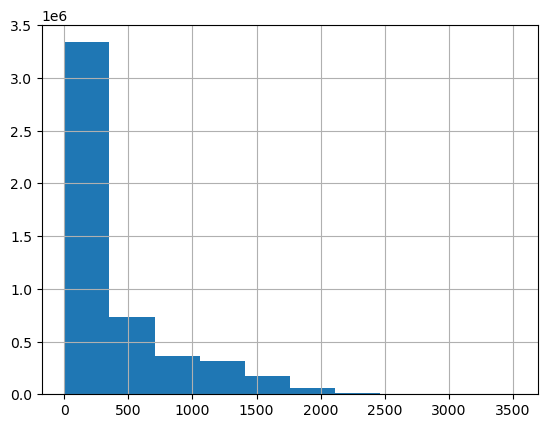

In [8]:
df['amount'].hist()

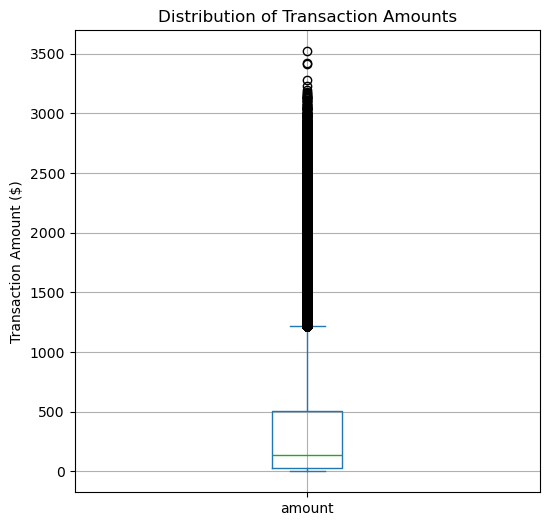

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

ax = df['amount'].plot(kind='box')

plt.title('Distribution of Transaction Amounts')
plt.ylabel('Transaction Amount ($)')

ax.set_xlabel('')   

plt.grid(True)

plt.savefig('transaction_amount_boxplot.png', dpi=300, bbox_inches='tight')

plt.show()

<Figure size 600x600 with 0 Axes>

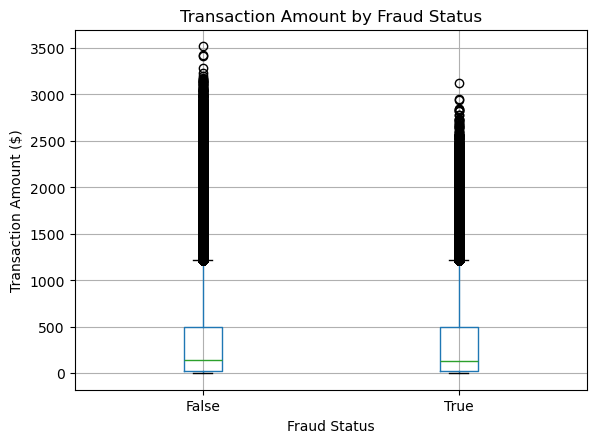

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

ax = df.boxplot(column='amount', by='is_fraud')

plt.title('Transaction Amount by Fraud Status')
plt.suptitle('')  # removes default pandas title
plt.ylabel('Transaction Amount ($)')
plt.xlabel('Fraud Status')

plt.grid(True)

# Save this one too
plt.savefig('amount_by_fraud_boxplot.png', dpi=300, bbox_inches='tight')

plt.show()

In [11]:
df['velocity_score'].describe()

count    5.000000e+06
mean     1.050132e+01
std      5.766842e+00
min      1.000000e+00
25%      5.000000e+00
50%      1.100000e+01
75%      1.600000e+01
max      2.000000e+01
Name: velocity_score, dtype: float64

<Axes: title={'center': 'velocity_score'}, xlabel='is_fraud'>

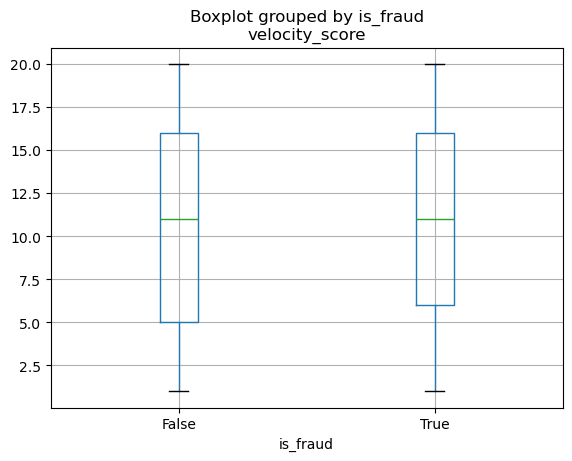

In [12]:
df.boxplot(column='velocity_score', by='is_fraud')

# Modelling

In [17]:
import pandas as pd

df = pd.read_csv("financial_fraud_detection_dataset.csv")

X = df.drop("is_fraud", axis=1)   # everything except target
y = df["is_fraud"]                # target column

#### Train/Test Split

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

 #### First Model (Baseline)

In [20]:
print(X.dtypes)

transaction_id                  object
timestamp                       object
sender_account                  object
receiver_account                object
amount                         float64
transaction_type                object
merchant_category               object
location                        object
device_used                     object
fraud_type                      object
time_since_last_transaction    float64
spending_deviation_score       float64
velocity_score                   int64
geo_anomaly_score              float64
payment_channel                 object
ip_address                      object
device_hash                     object
dtype: object


In [21]:
print(X.select_dtypes(include='object').columns)

Index(['transaction_id', 'timestamp', 'sender_account', 'receiver_account',
       'transaction_type', 'merchant_category', 'location', 'device_used',
       'fraud_type', 'payment_channel', 'ip_address', 'device_hash'],
      dtype='object')


In [23]:
print(X.select_dtypes(include='object').columns.tolist())

['transaction_id', 'timestamp', 'sender_account', 'receiver_account', 'transaction_type', 'merchant_category', 'location', 'device_used', 'fraud_type', 'payment_channel', 'ip_address', 'device_hash']


In [24]:
obj_cols = X.select_dtypes(include='object').columns

for col in obj_cols:
    print(col, X[col].nunique())

transaction_id 5000000
timestamp 4999998
sender_account 896513
receiver_account 896639
transaction_type 4
merchant_category 8
location 8
device_used 4
fraud_type 1
payment_channel 4
ip_address 4997068
device_hash 3835723


##### There were too many high-cardinality columns causing memory error. In order to create the first model, I dropped the high-cardinality identifier-like columns and kept the simple categorical ones.

In [25]:
cols_to_drop = [
    "transaction_id",
    "timestamp",
    "sender_account",
    "receiver_account",
    "ip_address",
    "device_hash"
]

X = df.drop(columns=cols_to_drop + ["is_fraud"])
y = df["is_fraud"]

##### Encoded the remaining categorical columns.

In [26]:
X = pd.get_dummies(X, drop_first=True)

##### Then split:

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

##### Logistic Regression

##### Ran into issue when trying to run regression. Errors occurred due to missing values (NaN). Logistic regression in scikit-learn does not accept missing values by default.

####### 1. Check with columns have missing values.  
####### print(x.isnull().sum()[x.isnull().sum > 0])   This will show only the columns that still have missing values.

In [30]:
print(X.isnull().sum()[X.isnull().sum() > 0])

time_since_last_transaction    896513
dtype: int64


##### To handle missing values, please do the following:

In [32]:
df_sample = df.sample(n=100000, random_state=42)

cols_to_drop = [
    "transaction_id",
    "timestamp",
    "sender_account",
    "receiver_account",
    "ip_address",
    "device_hash",
    "fraud_type"
]

X = df_sample.drop(columns=cols_to_drop + ["is_fraud"])
y = df_sample["is_fraud"]

# Fill missing values
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

X[num_cols] = X[num_cols].fillna(X[num_cols].median())
X[cat_cols] = X[cat_cols].fillna("Unknown")

# Encode categoricals
X = pd.get_dummies(X, drop_first=True)

##### Redo the split and model

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.96      0.52      0.68     19275
        True       0.04      0.48      0.07       725

    accuracy                           0.52     20000
   macro avg       0.50      0.50      0.37     20000
weighted avg       0.93      0.52      0.66     20000



#### Run full version in a fresh sequence

In [34]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

df_sample = df.sample(n=100000, random_state=42)

cols_to_drop = [
    "transaction_id",
    "timestamp",
    "sender_account",
    "receiver_account",
    "ip_address",
    "device_hash",
    "fraud_type"
]

X = df_sample.drop(columns=cols_to_drop + ["is_fraud"])
y = df_sample["is_fraud"]

num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

X[num_cols] = X[num_cols].fillna(X[num_cols].median())
X[cat_cols] = X[cat_cols].fillna("Unknown")

X = pd.get_dummies(X, drop_first=True)

print("Remaining NaNs:", X.isnull().sum().sum())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

Remaining NaNs: 0
              precision    recall  f1-score   support

       False       0.96      0.52      0.68     19275
        True       0.04      0.48      0.07       725

    accuracy                           0.52     20000
   macro avg       0.50      0.50      0.37     20000
weighted avg       0.93      0.52      0.66     20000



### Random Forest Model

In [36]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

       False       0.96      1.00      0.98     19275
        True       0.00      0.00      0.00       725

    accuracy                           0.96     20000
   macro avg       0.48      0.50      0.49     20000
weighted avg       0.93      0.96      0.95     20000



c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


###### The precision is ill-defined for one label because the model made no predicted samples for that class. The class is the fraud class (True).
###### This model is worse for fraud detection because it predicted everything as non-fraud. This is common in imbalanced datasets.
##### Try Random Forest with class balancing:

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf, zero_division=0))

              precision    recall  f1-score   support

       False       0.96      1.00      0.98     19275
        True       0.00      0.00      0.00       725

    accuracy                           0.96     20000
   macro avg       0.48      0.50      0.49     20000
weighted avg       0.93      0.96      0.95     20000



##### Still not catching fraud. It is stilling telling us that there is no fraud. 
##### Tweak the Random Forest code a bit.

In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight={0:1, 1:10}  # force model to care more about fraud
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf, zero_division=0))

              precision    recall  f1-score   support

       False       0.96      1.00      0.98     19275
        True       0.00      0.00      0.00       725

    accuracy                           0.96     20000
   macro avg       0.48      0.50      0.49     20000
weighted avg       0.93      0.96      0.95     20000



##### Adding threshold tuning to the logistic regression code, but change the last two lines:

In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

df_sample = df.sample(n=100000, random_state=42)

cols_to_drop = [
    "transaction_id",
    "timestamp",
    "sender_account",
    "receiver_account",
    "ip_address",
    "device_hash",
    "fraud_type"
]

X = df_sample.drop(columns=cols_to_drop + ["is_fraud"])
y = df_sample["is_fraud"]

num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

X[num_cols] = X[num_cols].fillna(X[num_cols].median())
X[cat_cols] = X[cat_cols].fillna("Unknown")

X = pd.get_dummies(X, drop_first=True)

print("Remaining NaNs:", X.isnull().sum().sum())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

y_probs = model.predict_proba(X_test)[:, 1]
y_pred_custom = (y_probs > 0.3).astype(int)

print(classification_report(y_test, y_pred_custom, zero_division=0))

Remaining NaNs: 0
              precision    recall  f1-score   support

       False       0.00      0.00      0.00     19275
        True       0.04      1.00      0.07       725

    accuracy                           0.04     20000
   macro avg       0.02      0.50      0.03     20000
weighted avg       0.00      0.04      0.00     20000



##### This is not a better model, as it is now telling me everything is fraud. The threshold increases fraud detection, but drastically increases false positives,
##### reducing precision. We need to find a better balance.

In [40]:
y_probs = model.predict_proba(X_test)[:, 1]

for t in [0.5, 0.4, 0.3, 0.2]:
    y_pred_custom = (y_probs > t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_custom, zero_division=0))


Threshold: 0.5
              precision    recall  f1-score   support

       False       0.96      0.52      0.68     19275
        True       0.04      0.48      0.07       725

    accuracy                           0.52     20000
   macro avg       0.50      0.50      0.37     20000
weighted avg       0.93      0.52      0.66     20000


Threshold: 0.4
              precision    recall  f1-score   support

       False       1.00      0.00      0.00     19275
        True       0.04      1.00      0.07       725

    accuracy                           0.04     20000
   macro avg       0.52      0.50      0.04     20000
weighted avg       0.97      0.04      0.00     20000


Threshold: 0.3
              precision    recall  f1-score   support

       False       0.00      0.00      0.00     19275
        True       0.04      1.00      0.07       725

    accuracy                           0.04     20000
   macro avg       0.02      0.50      0.03     20000
weighted avg       0.00   